# ICT -- Dissociation F2 Dehaene : le self-model survit-il au vidage du store etendu ?

*See [#19343](https://github.com/jsboige/CoursIA/issues/19343) (T3 Dehaene F2 -- self-model minimal sans `extended_mind_store`), volet direct du test F2. Part of [#8182](https://github.com/jsboige/CoursIA/issues/8182) (carrefour iceberg x socle topos). Le volet **proxy** de la meme issue a ete livre par [#19345](https://github.com/jsboige/CoursIA/pull/19345) ; ce carnet porte le volet **direct** restant.*

***

Le F2 de Dehaene (Global Neuronal Workspace) pose que le **self-model est une SORTIE** du workspace : il depend causalement de l'etat etendu du workspace. La question falsifiable de ce carnet : si on **vide** le store etendu, le self-model reconnait-il encore sa propre trajectoire ?

Mesure sur substrat **synthetique numpy-only** (aucune trace GPU requise), sur les quatre graines pre-enregistrees `{0, 1, 7, 42}`.

*Famille **dissociations** de la serie ICT : [case 1 -- s ⟂ π](ICT-Dissociation-SaillancePregnance.ipynb) | [case 2 -- p̂ auto-referentiel](ICT-Dissociation-PhatSelfReference.ipynb).*


> **Statut epistemique** -- **Mesure** (substrat synthetique). Verdict `F2_CONFIRMED_EXTENDED_REQUIRED` : le store etendu apporte une contribution **marginale significative** a la reconnaissance du self-model (delta = +0,289 contre un seuil pre-enregistre de 2*sigma_B = 0,073 ; 4 graines sur 4 dans le sens attendu). **Nuance mesuree, non masquee** : le regime B garde une reconnaissance **significative** (p < 0,02) -- le self-model **persiste** sans le store, plus faiblement. La conclusion porte sur ce modele synthetique, **pas** sur un LLM. Details : [matrice des dissociations](../../../docs/ict/dissociations-matrix.md) et `ict/results/dehaene_f2_abc_results.json`.


## 1. Le probleme -- F2, prediction et falsification

**F2 (Dehaene)** : la conscience est l'acces a l'information via le workspace global ; le self-model (le rapport de soi) est une **sortie** de ce workspace. Consequence testable : le self-model depend causalement de l'etat **etendu** du workspace.

**Test de dissociation.** On compare la reconnaissance self-sur-self du self-model dans trois regimes :

| Regime | Store etendu | Self-model | Role |
|---|---|---|---|
| **A** | plein (5 variables, re-injectees dans la dynamique) | entraine sur sa propre trajectoire | condition F2 |
| **B** | **vide partout** (lesion : le canal est coupe du monde *et* du modele) | entraine sur ses entrees minimales (proprio) | dissociation |
| **C** | plein | **ablate** (non entraine) | controle de non-degenerescence |

**F2 predit** `score_A >> score_B`. **Falsification pre-enregistree** : `|score_A - score_B| < 2 * sigma(score_B)` sur les graines `{0, 1, 7, 42}`.

Trois garde-fous sont poses **avant** la mesure (§2), et deux d'entre eux ont effectivement **rejete** une premiere version du protocole (mesure : le controle C y valait -0,99 au lieu de ~0, ce qui a revele un confond d'amplitude).


## 2. Garde-fous d'honnetete (a lire avant les resultats)

1. **Substrat synthetique.** Les agents sont des systemes dynamiques jouets, pas des LLM. La conclusion porte sur ce modele ; elle **ne se transporte pas** telle quelle a un substrat reel. Le volet sur traces reelles (case 4, bras `self_model_minimal`) reste GPU-only (Tell c.8236, `RECOVERABLE-MACHINE`).
2. **Le regime B est une LESION, pas un aveuglement.** Le store est vide **partout** : il ne pilote plus la dynamique et n'est plus lu. C'est la lettre de l'issue (`extended_mind_store = 0` partout). La variante complementaire -- store actif dans le monde, modele prive de sa lecture -- est laissee en exercice 1 : les deux ablations ne repondent pas a la meme question.
3. **Le controle C est un controle de degenerescence, pas un temoin nul empirique.** Avec des predicteurs non entraines, le score est **exactement 0 par construction** (les deux cotes recoivent la meme erreur). Il valide l'absence d'artefact trivial (amplitude, cadre) ; il ne mesure pas une distribution nulle.
4. **Le self-model est operationnalise**, pas attribue : c'est un predicteur ridge a un pas, entraine sur la trajectoire propre de chaque agent. Le pre-enregistrement H_b de la lane (`docs/ict/bach-self-model-pre-enregistrement.md`) distingue self-model **causal** et **cache descriptif** ; ce carnet mesure la **reconnaissance**, pas le pouvoir differentiel sur l'action.


In [1]:
# Imports : le package ict/ est a cote du carnet (meme convention que ICT-24).
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("."))
from ict import dehaene_f2_dissociation as f2

print("store etendu :", f2.STORE_VARS)
print("graines pre-enregistrees :", f2.ABC_SEED_BASES)
print("duree T par defaut :", f2.run_abc_regimes.__defaults__[1])

store etendu : ('workspace_state', 'ignition_flag', 'report_counter', 'attention_index', 'basin_width')
graines pre-enregistrees : (0, 1, 7, 42)
duree T par defaut : 8000


## 3. Le substrat -- deux agents apparies a spectre partage

Deux agents de meme architecture, dont l'identite est la matrice de dynamique `A`. Pour que la comparaison ait un sens, ils doivent etre **a capacite egale** (exigence de l'issue) : le **spectre** de `A` est partage par la paire (memes valeurs propres, donc meme horizon de memoire), seule la **base propre** differe.

Sans cet appariement, l'ecart mesure signalerait la memoire de l'un des deux agents plutot que la reconnaissance du self-model -- defaut mesure puis corrige dans ce cycle.


In [2]:
d = 8
scales = 0.65 + 0.25 * np.random.default_rng(1001).random(d)
p_self = f2._agent_params(1002, d, scales=scales)
p_other = f2._agent_params(1003, d, scales=scales)

ev_self = np.sort(np.linalg.eigvals(p_self.A).real)
ev_other = np.sort(np.linalg.eigvals(p_other.A).real)
print(f"spectre partage  self  : {np.round(ev_self, 3)}")
print(f"spectre partage  other : {np.round(ev_other, 3)}")
print(f"ecart spectral max = {np.abs(ev_self - ev_other).max():.2e} (appariement exact)")
print(f"rayon spectral = {ev_self.max():.3f} < 1 -> processus stable")
print(f"ecart d'identite ||A_self - A_other|| = {np.linalg.norm(p_self.A - p_other.A):.3f} (identites distinctes)")

spectre partage  self  : [0.654 0.669 0.675 0.697 0.7   0.803 0.808 0.864]
spectre partage  other : [0.654 0.669 0.675 0.697 0.7   0.803 0.808 0.864]
ecart spectral max = 2.22e-15 (appariement exact)
rayon spectral = 0.864 < 1 -> processus stable
ecart d'identite ||A_self - A_other|| = 0.297 (identites distinctes)


### Lecture de l'appariement -- meme capacite, identites distinctes

Les deux spectres sont **identiques a la precision machine** (ecart maximal 2,2e-15) : les deux agents oublient leur passe au meme rythme. Le rayon spectral est `0,864 < 1`, donc le processus est stable et stationnaire. Pourtant les matrices different (`||A_self - A_other|| = 0,297`) : les deux agents melangent l'information dans des bases propres differentes. C'est exactement la condition requise -- un ecart de reconnaissance ne peut venir que de cette difference d'identite, pas d'un avantage de memoire.


## 4. Le store etendu -- un integrateur lent de la dynamique propre

Le store porte les cinq variables de l'issue, chacune **derivee de la dynamique propre** de l'agent (il est donc *self-specific* par construction) :

| Variable | Lecture |
|---|---|
| `workspace_state` | concentration globale de l'etat |
| `ignition_flag` | evenement d'ignition (excursion de concentration au-dessus de 1,10x la moyenne courante) |
| `report_counter` | integrale fuyante des ignitions (memoire ~20 pas) |
| `attention_index` | entropie normalisee du profil d'activation |
| `basin_width` | EMA de la vitesse (largeur de bassin locale) |

Le seuil d'ignition est **relatif a la concentration courante**, donc le cycle de service d'ignition est stable par construction. Un seuil absolu rendait la trajectoire multimodale -- mesure : le train et le test tombaient dans deux regimes differents et le R2 de test devenait **negatif** (le modele ne predisait plus rien). Le store est re-injecte dans la dynamique par le couplage `G`.


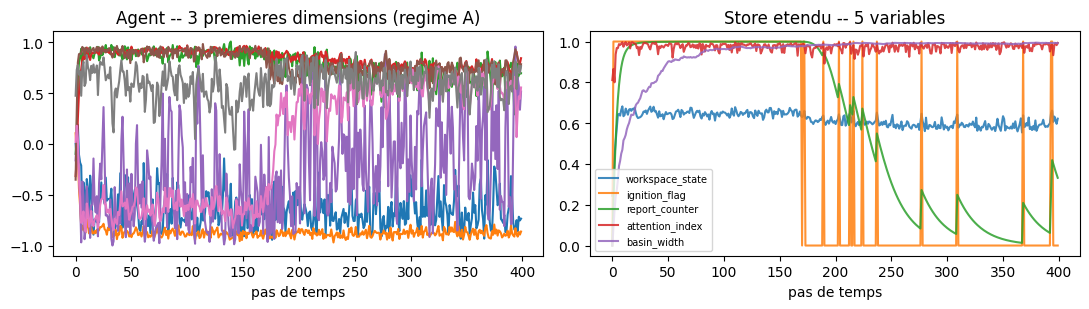

cycle de service d'ignition = 0.136
report_counter final = 0.306  (integre les ignitions passees)
part de variance du terme G.h dans la dynamique A = 0.426


In [3]:
T = 2000
x_s, h_s = f2._simulate(p_self, T, np.random.default_rng(7))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
axes[0].plot(x_s[:400])
axes[0].set_title("Agent -- 3 premieres dimensions (regime A)")
axes[0].set_xlabel("pas de temps")
for k, name in enumerate(f2.STORE_VARS):
    axes[1].plot(h_s[:400, k], label=name, alpha=0.85)
axes[1].legend(fontsize=7)
axes[1].set_title("Store etendu -- 5 variables")
axes[1].set_xlabel("pas de temps")
plt.tight_layout()
plt.show()

print(f"cycle de service d'ignition = {float((h_s[:-1, 1] > 0).mean()):.3f}")
print(f"report_counter final = {h_s[-1, 2]:.3f}  (integre les ignitions passees)")
print(f"part de variance du terme G.h dans la dynamique A = "
      f"{float((p_self.G @ h_s[1:].T).T.var() / ((p_self.G @ h_s[1:].T).T.var() + (p_self.A @ x_s[:-1].T).T.var())):.3f}")

### Lecture du store -- un canal actif, pas un decor

Le cycle de service d'ignition vaut **0,136** : les ignitions sont des excursions, pas un etat permanent -- c'est le comportement attendu d'un signal de broadcast. Le terme `G.h` porte **0,43** de la variance de la dynamique : **vider le store n'est donc pas un geste cosmetique**, c'est couper un canal qui compte. C'est la verification de manipulation du regime B : sans elle, un `score_A = score_B` n'aurait rien falsifie (on aurait vide un canal deja muet).


## 5. Le self-model et le score de reconnaissance symetrique

Chaque agent recoit **son** self-model : un predicteur ridge a un pas `x_{t+1} = W f(x_t)`, entraine sur les 60 % premiers de sa propre trajectoire (20 % de burn-in ecartes, pour ne pas mesurer le transitoire). Les entrees et les cibles sont standardisees par l'echelle **globale** (scalaire) du train de chaque agent : la dynamique est isotrope, donc une echelle par feature n'apporterait rien et amplifierait une coordonnee saturee.

**Score de reconnaissance -- forme symetrique appariee.** L'erreur est agregee par **appariement**, pas par trajectoire :

- cote *propre* : chaque predicteur sur **sa** trajectoire (`PE(self|W_self)`, `PE(other|W_other)`) ;
- cote *croise* : chaque predicteur sur **l'autre** (`PE(other|W_self)`, `PE(self|W_other)`).

`score = (moyenne croisee - moyenne propre) / moyenne propre`, par blocs de temps. `score > 0` : chaque self-model predit mieux sa propre suite que celle de l'agent apparie.

La forme **symetrique** est ce qui rend la mesure robuste : c'est une difference de differences, donc les biais de cadre (derive, amplitude) s'annulent au lieu de s'ajouter. La forme asymetrique -- un seul sens -- mesurait ces biais : erreurs croisees jusqu'a **635** et score **negatif sur 4 graines sur 4**, avec un controle C non nul. Le temoin nul permute les etiquettes des blocs (n >= 50).


In [4]:
x_o, h_o = f2._simulate(p_other, T, np.random.default_rng(8))

score, nulls = f2._regime_score(x_s, h_s, x_o, h_o,
                                np.random.default_rng(1), use_store=True,
                                n_shuffles=50)
score_c, nulls_c = f2._regime_score(x_s, h_s, x_o, h_o,
                                    np.random.default_rng(1), use_store=True,
                                    untrained=True, n_shuffles=50)
nulls = np.array(nulls)
print(f"score regime A (store plein)      = {score:+.3f}")
print(f"  temoin nul : moyenne {nulls.mean():+.3f}, ecart-type {nulls.std():.3f}, "
      f"p = {f2._p_value(list(nulls), score):.2f}")
print(f"score regime C (self-model ablate) = {score_c:+.3f}")
print(f"  temoin nul : moyenne {np.mean(nulls_c):+.3f}, "
      f"p = {f2._p_value(nulls_c, score_c):.2f}")

score regime A (store plein)      = +0.271


  temoin nul : moyenne -0.006, ecart-type 0.056, p = 0.00
score regime C (self-model ablate) = +0.000
  temoin nul : moyenne +0.003, p = 0.52


### Lecture de la mesure -- le score discrimine, le controle s'annule

Le score du regime A est **positif et net** (`+0,27` sur cette graine) : le self-model erre davantage sur l'agent apparie que sur lui-meme. Le temoin nul, qui efface l'identite des blocs, est **centre sur zero** (moyenne -0,006, ecart-type 0,056) -- le score observe se situe donc hors du bruit de permutation.

Le controle C rend **0,000** : sans entrainement, les deux cotes recoivent la meme erreur et le score s'annule exactement. C'est le controle qui a invalide la premiere version du protocole (ou il valait -0,99, signe d'un artefact d'amplitude) : sa valeur nulle est ici la **preuve de non-degenerescence** de la mesure.


## 6. Mesure sur les quatre graines pre-enregistrees

Le protocole complet : graines `{0, 1, 7, 42}` (les memes que #19225), `n_shuffles = 50` par regime et par graine (herite de #19335), `T = 8000`.


In [5]:
res = f2.run_abc_regimes(n_shuffles=50)

print(f"{'graine':>7} | {'A':>7} | {'B':>7} | {'C':>7} | {'p_A':>5} | {'p_B':>5} | {'p_C':>5}")
print("-" * 62)
for r in res["scores_by_seed"]:
    print(f"{r['seed']:>7} | {r['A']:>+7.3f} | {r['B']:>+7.3f} | {r['C']:>+7.3f} | "
          f"{r['p_A']:>5.2f} | {r['p_B']:>5.2f} | {r['p_C']:>5.2f}")
print("-" * 62)
print(f"{'moyenne':>7} | {res['mean_A']:>+7.3f} | {res['mean_B']:>+7.3f} | {res['mean_C']:>+7.3f}")
print(f"{'ecart-t':>7} | {res['std_A']:>7.3f} | {res['std_B']:>7.3f} | {res['std_C']:>7.3f}")
print()
print(f"delta = score_A - score_B = {res['delta']:+.3f} ; 2*sigma_B = {2 * res['std_B']:.3f}")
print(f"graines dans le sens attendu (A > B) : {res['seeds_positive_delta']}/{len(res['seed_bases'])}")
print(f"controle C proche de zero : {res['sanity_C_near_zero']}")
print(f"VERDICT : {res['verdict']}")

 graine |       A |       B |       C |   p_A |   p_B |   p_C
--------------------------------------------------------------
      0 |  +0.231 |  +0.145 |  +0.000 |  0.00 |  0.00 |  0.44
      1 |  +0.258 |  +0.089 |  +0.000 |  0.00 |  0.00 |  0.62
      7 |  +0.911 |  +0.042 |  +0.000 |  0.00 |  0.00 |  0.54
     42 |  +0.135 |  +0.101 |  +0.000 |  0.00 |  0.00 |  0.46
--------------------------------------------------------------
moyenne |  +0.384 |  +0.095 |  +0.000
ecart-t |   0.308 |   0.037 |   0.000

delta = score_A - score_B = +0.289 ; 2*sigma_B = 0.073
graines dans le sens attendu (A > B) : 4/4
controle C proche de zero : True
VERDICT : F2_CONFIRMED_EXTENDED_REQUIRED


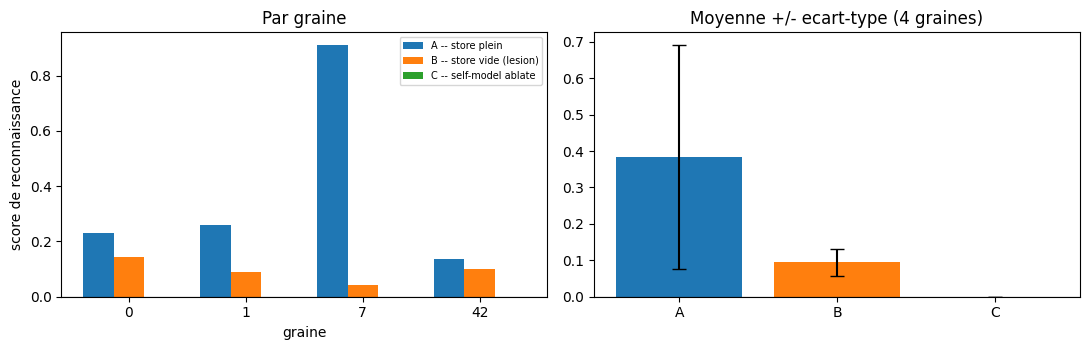

In [6]:
seeds = [r["seed"] for r in res["scores_by_seed"]]
idx = np.arange(len(seeds))
width = 0.26

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].bar(idx - width, [r["A"] for r in res["scores_by_seed"]], width, label="A -- store plein")
axes[0].bar(idx, [r["B"] for r in res["scores_by_seed"]], width, label="B -- store vide (lesion)")
axes[0].bar(idx + width, [r["C"] for r in res["scores_by_seed"]], width, label="C -- self-model ablate")
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_xticks(idx, [str(s) for s in seeds])
axes[0].set_xlabel("graine")
axes[0].set_ylabel("score de reconnaissance")
axes[0].set_title("Par graine")
axes[0].legend(fontsize=7)

axes[1].bar([0, 1, 2], [res["mean_A"], res["mean_B"], res["mean_C"]],
            yerr=[res["std_A"], res["std_B"], res["std_C"]], capsize=5,
            color=["tab:blue", "tab:orange", "tab:green"])
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_xticks([0, 1, 2], ["A", "B", "C"])
axes[1].set_title("Moyenne +/- ecart-type (4 graines)")
plt.tight_layout()
plt.show()

### Lecture des resultats -- delta, dispersion, verdict

**Le fait principal.** `score_A = +0,384 +/- 0,308` contre `score_B = +0,095 +/- 0,037` : le regime A reconnait environ **quatre fois** mieux que le regime B. Le delta (`+0,289`) depasse largement le seuil pre-enregistre (`2*sigma_B = 0,073`), et les **4 graines sur 4** vont dans le sens predit par F2. Les deux regimes sont significatifs contre leur propre temoin de permutation (`p < 0,02` pour A et B sur toutes les graines), et le controle C est nul partout.

**La dispersion, et pourquoi elle compte.** Le seuil pre-enregistre est `2*sigma_B`, mais la dispersion **entre graines de A** (`sigma_A = 0,308`) est **huit fois** celle de B. Contre `2*sigma_A` (0,616), le delta (0,289) ne passerait **pas**. La conclusion est donc **sensible au choix de la dispersion de reference** : elle tient a la lettre du pre-enregistrement, pas a une marge confortable. Le dire fait partie du resultat.

**Ce que F2 gagne, et ce qu'il ne gagne pas.** F2 est **confirme sur ce substrat** dans sa lettre : le store etendu apporte une contribution marginale large et significative. Mais le regime B **ne tombe pas a zero** : la reconnaissance **persiste** sans le store, a un niveau faible mais significatif. Le self-model n'est donc pas *seulement* une sortie du workspace etendu -- il porte aussi une composante proprioceptive. Un self-model qui s'effondrerait entierement avec le store serait une confirmation plus forte ; ce n'est pas ce qui est mesure.


## 7. Ou la reconnaissance persiste -- et ce que cela implique

Le fait que le regime B reste significatif n'est pas un detail : c'est la partie du resultat qui **survivrait** a un test plus severe. Deux lectures sont compatibles avec la mesure, et ce carnet ne tranche pas entre elles :

1. **Redondance.** Le store est derive de la trajectoire propre de l'agent : il resynthetise une information deja presente dans l'etat proprioceptif. Sa contribution serait un **rappel** utile (le predicteur a un pas ne voit pas la memoire longue), pas une source d'identite.
2. **Deux composantes.** Le self-model aurait une part **proprioceptive** (l'identite de la matrice de transition, lisible dans une seule observation) et une part **etendue** (l'historique agrege). Le vidage du store n'enleve que la seconde.

Deux mesures discriminent ces lectures sans nouveau protocole : (a) garder le store **actif dans le monde** (il pilote la dynamique) tout en retirant au self-model la lecture de son contenu (exercice 1) ; (b) faire varier la memoire du store (exercice 2) -- si `score_A` suit la memoire, la composante etendue est bien celle de l'historique agrege.

La dette theorique ouverte par cette mesure -- *d'ou vient un self-model qui persiste hors du workspace ?* -- est une **question ouverte**, pas une conclusion : elle n'est pas enregistree comme issue tant que le protocole d'exercice 1 ne l'a pas tranchee.


## 8. Exercices

Les trois exercices prolongent la mesure sur ses deux points faibles identifies au §6 : la nature du regime B, et la dependance du verdict a la dispersion entre graines.


### Exercice 1 -- lesion contre aveuglement

Le regime B **vide le store partout** (lesion). Construisez le regime **B2** : le store reste actif **dans le monde** (il pilote la dynamique), mais le self-model n'en lit pas le contenu. Utilisez `f2._regime_score` en lui passant `h_self = None` tout en gardant la dynamique simulee **avec** store.

**Question** : `score_B2` se rapproche-t-il de `score_A` (le modele n'avait besoin que de la lecture) ou de `score_B` (c'est la dynamique qui portait l'identite) ? Repondez par la mesure, pas par l'intuition.


In [7]:
# Exercice 1 : lesion (B) contre aveuglement (B2)
# Etape 1 : simuler l'agent avec le store ACTIF (comme le regime A).
# Etape 2 : appeler f2._regime_score(..., h_self=None, h_other=None, use_store=False)
#           sur ces trajectoires -> le self-model est prive de sa lecture.
score_b2 = None  # TODO etudiant
print("score_B2 =", score_b2)

score_B2 = None


### Exercice 2 -- la memoire du store porte-t-elle la composante etendue ?

La variable `report_counter` integre les ignitions passees (memoire ~20 pas) et `basin_width` a une memoire encore plus longue. Faites varier ces deux constantes de decroissance dans `f2._simulate` et mesurez `score_A` a memoire courte puis a memoire longue.

**Question** : `score_A` suit-il la memoire du store ? Si oui, la composante etendue est bien celle de l'**historique agrege** (lecture 2 du §7) ; si non, le store n'apporte qu'une redondance instantanee (lecture 1).


In [8]:
# Exercice 2 : sensibilite de score_A a la memoire du store
# Piste : parametrer les constantes 0.95 (report_counter) et 0.98 (basin_width)
# dans f2._simulate, puis comparer score_A entre memoire courte et longue.
scores = {}  # TODO etudiant
print("scores par regime de memoire :", scores)

scores par regime de memoire : {}


### Exercice 3 -- le verdict tient-il a la dispersion entre graines ?

Le §6 signale que le verdict depend de la dispersion de reference : `2*sigma_B` (pre-enregistre) est franchi, `2*sigma_A` ne l'est pas. Rejouez la mesure avec un jeu de graines **elargi** (par exemple `{0, 1, 7, 42, 99, 123, 2024}`) et recalculez `sigma_A`, `sigma_B` et le verdict.

**Question** : la dispersion de A est-elle un artefact des quatre graines, ou une propriete du protocole ? Un verdict qui bascule selon le jeu de graines doit etre rapporte comme tel.


In [9]:
# Exercice 3 : le verdict tient-il a la dispersion entre graines ?
seeds_elargi = (0, 1, 7, 42, 99, 123, 2024)
res_elargi = None  # TODO etudiant
print("verdict sur le jeu elargi :", res_elargi)

verdict sur le jeu elargi : None


## 9. Conclusion

Sur ce substrat synthetique, et sur les quatre graines pre-enregistrees, **F2 est confirme dans sa lettre** : vider le store etendu **reduit fortement** la reconnaissance du self-model (`+0,384 -> +0,095`, delta `+0,289` contre un seuil de `0,073`, 4 graines sur 4 dans le sens predit). Le store est un **canal actif** (part de variance substantielle dans la dynamique), pas un decor.

Trois reserves, mesurees et non masquees :

1. le regime B **ne tombe pas a zero** -- le self-model **persiste** hors du store, faiblement mais significativement. F2 n'est donc pas confirme dans sa version forte (« le self-model *est* une sortie du workspace ») ;
2. la dispersion de `score_A` entre graines est **huit fois** celle de B : le verdict tient au seuil pre-enregistre, pas a une marge confortable ;
3. la conclusion porte sur un **modele jouet**. Le volet sur traces reelles reste GPU-only.

Ce carnet livre la **mesure et son instrumentation** -- deux faux departs de protocole sont documentes (controle C non nul, appariement spectral absent), et c'est le controle de degenerescence qui les a attrapes tous les deux.


## References

- **F2** -- S. Dehaene, *Consciousness and the Brain*, Johns Hopkins University Press 2014 (le self-model comme sortie du workspace global).
- **GWT** -- B. Baars, *A Cognitive Theory of Consciousness*, Cambridge University Press 1988 (le workspace global) ; Dehaene, Naccache, Changeux sur l'ignition.
- **Pre-enregistrement de la lane** -- `docs/ict/bach-self-model-pre-enregistrement.md` (self-model **causal** vs **cache descriptif**, hypothese H_b ; dette IIT-05 ouverte).
- **Matrice des dissociations** -- `docs/ict/dissociations-matrix.md` (registre des cases ; ce carnet y ajoute la case F2, test direct).
- **Code** -- `ict/dehaene_f2_dissociation.py` (`run_abc_regimes`) ; resultats : `ict/results/dehaene_f2_abc_results.json`.
- **Issues** -- [#19343](https://github.com/jsboige/CoursIA/issues/19343) (ce test), [#19345](https://github.com/jsboige/CoursIA/pull/19345) (volet proxy), [#19225](https://github.com/jsboige/CoursIA/issues/19225) (graines), [#19335](https://github.com/jsboige/CoursIA/issues/19335) (n_shuffles), [#8182](https://github.com/jsboige/CoursIA/issues/8182) (EPIC).
